# Notebook 04 — Escalamiento y PCA
## Proyecto Integrador — Minería de Datos I
**Integrantes:** Valeria Martinetti y Santiago Gallardo

---

### Objetivo de este notebook

Aplicar Análisis de Componentes Principales (PCA) sobre las variables numéricas del dataset limpio.  
El propósito es identificar si existe una estructura latente en los datos que permita distinguir grupos de usuarios según su comportamiento, y en particular, evaluar si el plan de suscripción produce alguna separación en el espacio dimensional reducido.

## 1. Setup y carga de datos

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/processed/streaming_users_clean.csv')
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 8,034 filas × 8 columnas


## 2. Selección de variables

PCA solo puede operar sobre variables numéricas continuas. Del dataset seleccionamos las tres variables cuantitativas con significado analítico real:

| Variable | Tipo | Rango aproximado |
|---|---|---|
| `age` | Discreta (años) | 0 – 100 |
| `monthly_watch_time_mins` | Continua (minutos/mes) | 0 – ~2693 (winsorizado) |
| `customer_support_tickets` | Discreta (conteo) | 0 – 4 (winsorizado) |

> Se excluye `user_id` por ser un identificador, y `last_login_date` por ser una fecha no comparable numéricamente de forma directa.

In [23]:
FEATURES = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']

X = df[FEATURES].copy()

print("Estadísticos de las variables seleccionadas:")
print(X.describe().round(2))

Estadísticos de las variables seleccionadas:
           age  monthly_watch_time_mins  customer_support_tickets
count  8034.00                  8034.00                   8034.00
mean     33.61                   782.70                      0.80
std      11.56                   427.78                      0.89
min       4.00                     0.00                      0.00
25%      25.00                   499.68                      0.00
50%      33.00                   758.50                      1.00
75%      41.00                  1029.22                      1.00
max      80.00                  2693.40                      4.00


## 3. Escalamiento (StandardScaler)

### ¿Por qué es necesario escalar?

PCA construye componentes en función de la varianza de cada variable. Si no escalamos, `monthly_watch_time_mins` (valores en el orden de los miles) dominaría completamente el análisis sobre `customer_support_tickets` (valores entre 0 y 4), simplemente por la diferencia de escala y no por su importancia real.

`StandardScaler` transforma cada variable para que tenga media = 0 y desvío estándar = 1, igualando sus pesos antes de que PCA calcule las direcciones de máxima varianza.

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar resultado del escalamiento
df_scaled = pd.DataFrame(X_scaled, columns=FEATURES)
print("Media de cada variable escalada (debe ser ≈ 0):")
print(df_scaled.mean().round(6))
print("\nDesvío estándar de cada variable escalada (debe ser ≈ 1):")
print(df_scaled.std().round(6))

Media de cada variable escalada (debe ser ≈ 0):
age                        -0.0
monthly_watch_time_mins     0.0
customer_support_tickets    0.0
dtype: float64

Desvío estándar de cada variable escalada (debe ser ≈ 1):
age                         1.000062
monthly_watch_time_mins     1.000062
customer_support_tickets    1.000062
dtype: float64


## 4. Aplicación de PCA

Con 3 variables numéricas, PCA puede generar como máximo 3 componentes principales. Cada componente es una combinación lineal de las variables originales, orientada en la dirección de máxima varianza no capturada por los componentes anteriores.

In [25]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza_individual  = pca.explained_variance_ratio_
varianza_acumulada   = np.cumsum(varianza_individual)

resumen_varianza = pd.DataFrame({
    'Componente'         : ['PC1', 'PC2', 'PC3'],
    'Varianza explicada' : (varianza_individual * 100).round(2),
    'Varianza acumulada' : (varianza_acumulada   * 100).round(2)
})
print(resumen_varianza.to_string(index=False))
print(f"\nTotal varianza con 3 componentes: {varianza_acumulada[-1]*100:.1f}%")

Componente  Varianza explicada  Varianza acumulada
       PC1               33.66               33.66
       PC2               33.28               66.94
       PC3               33.06              100.00

Total varianza con 3 componentes: 100.0%


## 5. Cargas de los componentes (Loadings)

Las cargas indican qué tan fuertemente contribuye cada variable original a cada componente principal. Un valor cercano a ±1 indica contribución alta; cercano a 0 indica contribución baja.

In [26]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2', 'PC3']
).round(4)

print("Cargas (loadings) de cada variable por componente:")
print(loadings)

Cargas (loadings) de cada variable por componente:
                             PC1     PC2     PC3
age                       0.6733 -0.1209  0.7294
monthly_watch_time_mins   0.4034  0.8868 -0.2254
customer_support_tickets  0.6196 -0.4460 -0.6459


## 6. Visualización 1 — Gráfico de Sedimentación (Scree Plot)

Muestra cuánta varianza explica cada componente individual (barras) y la acumulada (línea).

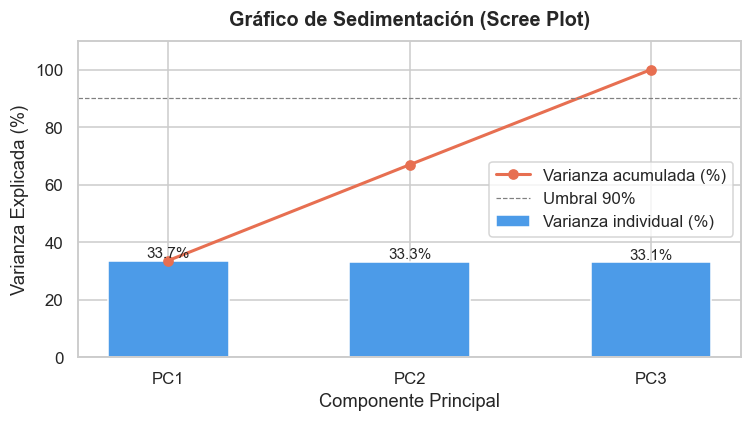

In [27]:
componentes = [1, 2, 3]

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(componentes,
       varianza_individual * 100,
       color='#4C9BE8',
       edgecolor='white',
       width=0.5,
       label='Varianza individual (%)')

ax.plot(componentes,
        varianza_acumulada * 100,
        color='#E76F51',
        marker='o',
        linewidth=2,
        label='Varianza acumulada (%)')

# Anotar los porcentajes en las barras
for i, v in enumerate(varianza_individual * 100):
    ax.text(i + 1, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

ax.axhline(90, color='gray', linestyle='--', linewidth=0.8, label='Umbral 90%')

ax.set_xticks(componentes)
ax.set_xticklabels(['PC1', 'PC2', 'PC3'])
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza Explicada (%)')
ax.set_title('Gráfico de Sedimentación (Scree Plot)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0, 110)
ax.legend()

plt.tight_layout()
plt.show()

El gráfico no presenta un "codo" pronunciado entre componentes. La varianza está distribuida de forma bastante pareja entre las tres componentes (aproximadamente un tercio cada una), lo que indica que las tres variables originales son prácticamente ortogonales entre sí, es decir, no están correlacionadas.

Para superar el umbral del 90% de varianza explicada se necesitan los 3 componentes, lo que confirma que ninguna combinación de solo dos variables captura suficientemente la estructura de los datos.

## 7. Visualización 2 — Biplot (Proyección en PC1 y PC2)

Se proyectan todos los usuarios en el plano de los dos primeros componentes, coloreando por plan de suscripción.

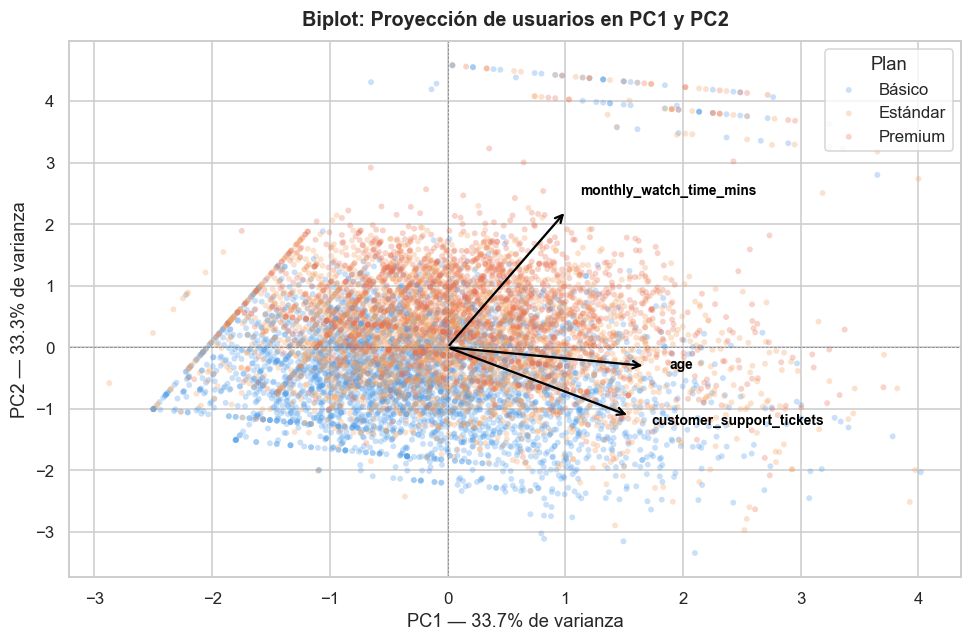

In [28]:
PLAN_ORDEN   = ['Básico', 'Estándar', 'Premium']
PLAN_PALETA = {'Básico': '#4C9BE8', 'Estándar': '#F4A261', 'Premium': '#E76F51'}

# Añadir coordenadas PCA y plan al dataframe de trabajo
df_plot = df[['subscription_plan']].copy()
df_plot['PC1'] = X_pca[:, 0]
df_plot['PC2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))

for plan in PLAN_ORDEN:
    subset = df_plot[df_plot['subscription_plan'] == plan]
    ax.scatter(subset['PC1'], subset['PC2'],
               label=plan,
               color=PLAN_PALETA[plan],
               alpha=0.3,
               s=15,
               edgecolors='none')

# Vectores de carga (flechas)
escala = 2.5
for i, feature in enumerate(FEATURES):
    ax.annotate('',
                xy=(pca.components_[0, i] * escala,
                    pca.components_[1, i] * escala),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(pca.components_[0, i] * escala * 1.12,
            pca.components_[1, i] * escala * 1.12,
            feature,
            fontsize=9, color='black', fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'PC1 — {varianza_individual[0]*100:.1f}% de varianza')
ax.set_ylabel(f'PC2 — {varianza_individual[1]*100:.1f}% de varianza')
ax.set_title('Biplot: Proyección de usuarios en PC1 y PC2',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(title='Plan', loc='upper right')

plt.tight_layout()
plt.show()

Al proyectar los 8034 usuarios en el plano PC1–PC2, se observa una nube densa sin estructura de clústeres separables. Los tres planes de suscripción, Básico, Estándar y Premium aparecen completamente superpuestos, sin que ninguno ocupe una región diferenciada del espacio.

Los vectores de carga muestran que las tres variables originales contribuyen en direcciones distintas, lo que confirma su baja correlación mutua. Ninguna combinación de ellas logra separar a los usuarios por plan.

Este resultado es coherente con el EDA: si el tiempo de visualización, la edad y los tickets de soporte no varían sistemáticamente según el plan, PCA tampoco puede generar componentes que separen esos grupos.

## 8. Conclusión del análisis PCA

| Aspecto | Resultado |
|---|---|
| Variables utilizadas | `age`, `monthly_watch_time_mins`, `customer_support_tickets` |
| Escalamiento | StandardScaler (media=0, std=1) |
| Componentes necesarios para superar 90% | 3 de 3 |
| Varianza por componente | ~33% c/u (distribución uniforme) |
| Clústeres por plan en biplot | No detectados |

La ausencia de un "codo" en el scree plot y la nube indiferenciada del biplot son consecuencias directas de la homogeneidad detectada en el EDA: cuando las variables no co-varían de forma sistemática con el plan de suscripción, PCA no puede construir componentes que los separen. Esto refuerza la conclusión central del proyecto.